In [138]:
import pandas as pd
df = pd.read_csv("../data/house_prices.csv")
df.head()


,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,has_garage,quality_score,school_rating,building_material,heating_type,price_k_usd
0,1000,1660,4,2.5,13501,28.8,2015,Yes,8,5,Stone,Gas,1077.78
1,1001,4572,5,3.5,10010,24.0,1986,No,6,4,Brick,Gas,1165.15
2,1002,3892,2,2.5,7959,12.6,1973,Yes,5,4,Wood,Electric,1077.08
3,1003,1266,4,2.0,9269,29.5,2011,Yes,5,4,Brick,Gas,919.52
4,1004,4244,5,2.5,9692,11.0,1970,Yes,3,2,Brick,Gas,1073.88


In [139]:
df.shape

(10000, 13)

In [140]:
#Adding location column 
#df["Location"] = df["distance_to_city_center_km"].apply(
#    lambda x: "Urban" if x < 12.5 else "Rural"
#)

import numpy as np

df["Location"] = np.where(df["distance_to_city_center_km"] < 12.5 , "Urban", "Rural")

df.head()

,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,has_garage,quality_score,school_rating,building_material,heating_type,price_k_usd,Location
0,1000,1660,4,2.5,13501,28.8,2015,Yes,8,5,Stone,Gas,1077.78,Rural
1,1001,4572,5,3.5,10010,24.0,1986,No,6,4,Brick,Gas,1165.15,Rural
2,1002,3892,2,2.5,7959,12.6,1973,Yes,5,4,Wood,Electric,1077.08,Rural
3,1003,1266,4,2.0,9269,29.5,2011,Yes,5,4,Brick,Gas,919.52,Rural
4,1004,4244,5,2.5,9692,11.0,1970,Yes,3,2,Brick,Gas,1073.88,Urban


In [141]:
#Checking for null entries
df.isna().sum()

house_id                      0
square_footage                0
number_of_rooms               0
number_of_bathrooms           0
lot_size_sqft                 0
distance_to_city_center_km    0
year_built                    0
has_garage                    0
quality_score                 0
school_rating                 0
building_material             0
heating_type                  0
price_k_usd                   0
Location                      0
dtype: int64

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   house_id                    10000 non-null  int64  
 1   square_footage              10000 non-null  int64  
 2   number_of_rooms             10000 non-null  int64  
 3   number_of_bathrooms         10000 non-null  float64
 4   lot_size_sqft               10000 non-null  int64  
 5   distance_to_city_center_km  10000 non-null  float64
 6   year_built                  10000 non-null  int64  
 7   has_garage                  10000 non-null  str    
 8   quality_score               10000 non-null  int64  
 9   school_rating               10000 non-null  int64  
 10  building_material           10000 non-null  str    
 11  heating_type                10000 non-null  str    
 12  price_k_usd                 10000 non-null  float64
 13  Location                    10000 non-null 

In [143]:
df.describe()

,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,quality_score,school_rating,price_k_usd
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5999.50000,2906.349800,3.506800,2.277100,9523.834300,15.497810,1986.791200,6.508800,3.006800,1026.916494
std,2886.89568,1207.433822,1.114127,0.796322,3185.060018,8.362935,21.351946,2.287498,1.424485,192.863307
min,1000.00000,801.000000,2.000000,1.000000,4000.000000,1.000000,1950.000000,3.000000,1.000000,400.100000
25%,3499.75000,1847.500000,3.000000,2.000000,6774.750000,8.300000,1968.000000,4.000000,2.000000,889.025000
50%,5999.50000,2905.000000,4.000000,2.000000,9568.000000,15.400000,1987.000000,6.000000,3.000000,1027.705000
75%,8499.25000,3963.250000,5.000000,3.000000,12314.750000,22.700000,2005.000000,9.000000,4.000000,1167.295000
max,10999.00000,4999.000000,5.000000,4.000000,14999.000000,30.000000,2023.000000,10.000000,5.000000,1784.320000


In [144]:
df[["square_footage", "price_k_usd"]].describe()

,square_footage,price_k_usd
count,10000.000000,10000.000000
mean,2906.349800,1026.916494
std,1207.433822,192.863307
min,801.000000,400.100000
25%,1847.500000,889.025000
50%,2905.000000,1027.705000
75%,3963.250000,1167.295000
max,4999.000000,1784.320000


In [145]:
df.shape

(10000, 14)

In [146]:
#Identifying outliers
Q1 = df["price_k_usd"].quantile(0.25)
Q3 = df["price_k_usd"].quantile(0.75)

IQR = Q3 - Q1

lowest_point = Q1 - 1.5*IQR
highest_point = Q3 + 1.5*IQR

outliers = df[(df["price_k_usd"] < lowest_point) | (df["price_k_usd"] > highest_point)]

outliers.shape

(20, 14)

In [147]:
#Removing Outliers
After_remo_outliers = df[(df["price_k_usd"] > lowest_point) & (df["price_k_usd"] < highest_point)]
After_remo_outliers.shape

(9980, 14)

In [148]:
df = After_remo_outliers.copy()
df.shape

(9980, 14)

In [149]:
#Normalisation of data
#Using Min-MaxScaling

#Standardisation of data using StandardScaler or MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

features = After_remo_outliers[['square_footage','number_of_rooms']]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,square_footage,number_of_rooms
0,0.204621,0.666667
1,0.898285,1.000000
2,0.736303,0.000000
3,0.110767,0.666667
4,0.820152,1.000000


In [150]:
After_remo_outliers.shape

(9980, 14)

In [151]:
#df['Location'] = pd.get_dummies(df['Location'], columns=['Location'], drop_first=True).astype(int)
df = pd.get_dummies(df, columns=['Location'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,has_garage,quality_score,school_rating,building_material,heating_type,price_k_usd,Location
0,1000,1660,4,2.5,13501,28.8,2015,Yes,8,5,Stone,Gas,1077.78,0
1,1001,4572,5,3.5,10010,24.0,1986,No,6,4,Brick,Gas,1165.15,0
2,1002,3892,2,2.5,7959,12.6,1973,Yes,5,4,Wood,Electric,1077.08,0
3,1003,1266,4,2.0,9269,29.5,2011,Yes,5,4,Brick,Gas,919.52,0
4,1004,4244,5,2.5,9692,11.0,1970,Yes,3,2,Brick,Gas,1073.88,1


In [152]:
df.corr(numeric_only = True)

,house_id,square_footage,number_of_rooms,number_of_bathrooms,lot_size_sqft,distance_to_city_center_km,year_built,quality_score,school_rating,price_k_usd,Location
house_id,1.000000,-0.027963,-0.007631,0.009099,-0.017996,0.013180,0.002023,0.015184,0.007935,-0.010362,-0.009409
square_footage,-0.027963,1.000000,0.003507,-0.004629,0.007014,0.005507,-0.000460,-0.004626,-0.012616,0.745768,0.006884
number_of_rooms,-0.007631,0.003507,1.000000,-0.001755,0.000579,-0.007066,-0.020259,0.002600,0.000735,0.106316,0.002226
number_of_bathrooms,0.009099,-0.004629,-0.001755,1.000000,-0.009400,-0.007341,0.011756,0.006927,0.007911,0.186170,0.008464
lot_size_sqft,-0.017996,0.007014,0.000579,-0.009400,1.000000,-0.011187,0.001748,-0.010924,-0.006848,0.083745,0.015520
distance_to_city_center_km,0.013180,0.005507,-0.007066,-0.007341,-0.011187,1.000000,-0.008840,0.009329,0.001395,-0.170285,-0.846630
year_built,0.002023,-0.000460,-0.020259,0.011756,0.001748,-0.008840,1.000000,0.001371,-0.012816,0.197611,0.013650
quality_score,0.015184,-0.004626,0.002600,0.006927,-0.010924,0.009329,0.001371,1.000000,-0.013089,0.348952,-0.010798
school_rating,0.007935,-0.012616,0.000735,0.007911,-0.006848,0.001395,-0.012816,-0.013089,1.000000,0.247293,0.002674
price_k_usd,-0.010362,0.745768,0.106316,0.186170,0.083745,-0.170285,0.197611,0.348952,0.247293,1.000000,0.156624


In [153]:
df.corr(numeric_only=True)["price_k_usd"].sort_values(ascending=False)

price_k_usd                   1.000000
square_footage                0.745768
quality_score                 0.348952
school_rating                 0.247293
year_built                    0.197611
number_of_bathrooms           0.186170
Location                      0.156624
number_of_rooms               0.106316
lot_size_sqft                 0.083745
house_id                     -0.010362
distance_to_city_center_km   -0.170285
Name: price_k_usd, dtype: float64

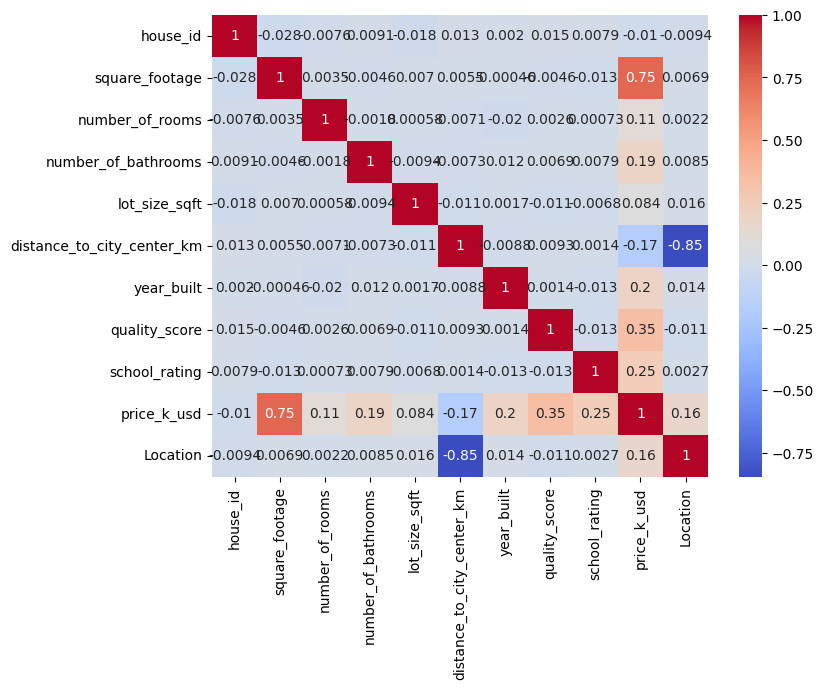

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Inference of heat map

Size of house shows a strong positive correlation **0.75** with Price, indicating larger houses tend to be more expensive.

Distance to city center has a negative correlation **-0.17** with Price, suggesting properties farther away are cheaper.

Location (urban or rural) has moderate positive correlation **0.156**, meaning urban properties are generally priced higher.

In [156]:
#Removing low impact features 0 < corr < 0.01
low_corr_features = ["number_of_rooms", "lot_size_sqft"]  # example

df = df.drop(columns=low_corr_features)
df.head()

,house_id,square_footage,number_of_bathrooms,distance_to_city_center_km,year_built,has_garage,quality_score,school_rating,building_material,heating_type,price_k_usd,Location
0,1000,1660,2.5,28.8,2015,Yes,8,5,Stone,Gas,1077.78,0
1,1001,4572,3.5,24.0,1986,No,6,4,Brick,Gas,1165.15,0
2,1002,3892,2.5,12.6,1973,Yes,5,4,Wood,Electric,1077.08,0
3,1003,1266,2.0,29.5,2011,Yes,5,4,Brick,Gas,919.52,0
4,1004,4244,2.5,11.0,1970,Yes,3,2,Brick,Gas,1073.88,1


In [161]:
# Model Training 
# Data splitting
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

X = df[['square_footage','quality_score', 'school_rating', 'year_built', 'number_of_bathrooms', 'Location', 'distance_to_city_center_km']]
y = df['price_k_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


RMSE: 72.58546586382288
R2 Score: 0.8566557354356041


In [162]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

X = df[['square_footage','quality_score', 'school_rating', 'year_built', 'number_of_bathrooms', ]]
y = df['price_k_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


RMSE: 79.83676168672224
R2 Score: 0.8265849403701684


In [164]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

X = df[['square_footage','quality_score' ]]
y = df['price_k_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


RMSE: 107.07868520282135
R2 Score: 0.6880485248874225


Multiple models were trained using different feature sets to evaluate their impact on performance. The model with all relevant features achieved the best performance (R² = 0.856, RMSE = 72.58), indicating that additional variables such as location and distance significantly improve predictive accuracy. Reducing features led to a decline in performance, demonstrating the importance of including meaningful predictors.

In [168]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred,
    "Difference(entrpy)": y_test-y_pred
})

results.head(10)

,Actual Price,Predicted Price,Difference(entrpy)
1255,1391.71,1288.481185,103.228815
8239,1042.35,1021.308717,21.041283
1663,1350.21,1368.835062,-18.625062
7748,1040.85,1024.945407,15.904593
1444,1303.38,1279.118417,24.261583
1058,1261.59,990.152187,271.437813
35,943.34,803.801065,139.538935
7164,1140.30,937.443260,202.856740
1667,1177.14,1123.002076,54.137924
4058,932.87,1084.646780,-151.776780


In [169]:
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 107.07868520282135
R2 Score: 0.6880485248874225


### 2) Feature Insights

Correlation values :
Positive coefficient → increases price
Negative coefficient → decreases price
Larger value → stronger impact

#### What we observed (based on our results)

We already proved:
🟢 Strong predictors:
square_footage → biggest impact
quality_score → strong influence
location / distance → very important

🟡 Moderate:
school_rating
number_of_bathrooms


Square footage is the most influential factor, showing a strong positive relationship with house prices, indicating that larger homes are significantly more expensive.

Quality score also has a strong positive impact, suggesting that better construction and amenities increase property value.

Location-related features such as distance from the city center play a crucial role, with properties closer to urban areas generally priced higher.

Additional features like school rating and number of bathrooms contribute moderately to price variation.

### 3) Model Accuracy Insight

R² ≈ 0.856  
RMSE ≈ 72.5

The regression model demonstrates strong predictive performance, with an R² score of approximately 0.856, indicating that over 85% of the variance in house prices is explained by the model. The RMSE value suggests relatively low prediction error, making the model reasonably reliable for real-world price estimation.